In [1]:
using NeuralPDE, Lux, LuxCUDA, Optimization, OptimizationOptimJL
using ModelingToolkit, IntervalSets, Plots, JLD2
using ComponentArrays, Random
using Plots
const gpud = gpu_device()


┌ Warning: No functional GPU backend found! Defaulting to CPU.
│ 
│ 1. If no GPU is available, nothing needs to be done. Set `MLDATADEVICES_SILENCE_WARN_NO_GPU=1` to silence this warning.
│ 2. If GPU is available, load the corresponding trigger package.
│     a. `CUDA.jl` and `cuDNN.jl` (or just `LuxCUDA.jl`) for  NVIDIA CUDA Support.
│     b. `AMDGPU.jl` for AMD GPU ROCM Support.
│     c. `Metal.jl` for Apple Metal GPU Support. (Experimental)
│     d. `oneAPI.jl` for Intel oneAPI GPU Support. (Experimental)
└ @ MLDataDevices.Internal /Users/reula/.julia/packages/MLDataDevices/NeohJ/src/internal.jl:112


(::CPUDevice{Missing}) (generic function with 1 method)

In [2]:


@parameters t, x, y, z
@variables u(..)
Dx = Differential(x)
Dy = Differential(y)
Dz = Differential(z)
Dt = Differential(t)
Dxx = Differential(x)^2
Dyy = Differential(y)^2
Dzz = Differential(z)^2
Dtt = Differential(t)^2

#2D PDE
C = 1
L = 10
p = 8
r0 = 0.1*L
eq = Dtt(u(t,x,y,z)) ~ C^2 * (Dxx(u(t,x,y,z)) + Dyy(u(t,x,y,z)) + Dzz(u(t,x,y,z)))
r(x,y,z) = sqrt(x^2 + y^2 + z^2)


r (generic function with 1 method)

In [3]:


# Initial and boundary conditions
bcs = [Dt(u(t, -L, y, z)) - L/r(-L, y, z)*Dx(u(t, -L, y, z)) ~ u(t, -L, y, z)/r(-L, y, z),   # for all t > 0
    Dt(u(t, L , y, z)) + L/r( L, y, z)*Dx(u(t, L , y, z)) ~ u(t, L , y, z)/r( L, y, z),# for all t > 0
    Dt(u(t, x, -L, z)) - L/r(x, -L, z)*Dy(u(t, x, -L, z)) ~ u(t, x, -L, z)/r(x, -L, z),   # for all t > 0
    Dt(u(t, x, L , z)) + L/r(x,  L, z)*Dy(u(t, x,  L, z)) ~ u(t, x,  L, z)/r(x,  L, z),# for all t > 0
    Dt(u(t, x, y, -L)) - L/r(x, y, -L)*Dz(u(t, x, y, -L)) ~ u(t, x, y, -L)/r(x, y, -L),   # for all t > 0
    Dt(u(t, x, y,  L)) + L/r(x, y,  L)*Dz(u(t, x, y,  L)) ~ u(t, x, y,  L)/r(x, y,  L),# for all t > 0
    u(0, x) ~ exp(-(r(x,y,z) - L/4)^2/r0^2), #for all 0 < x < 1
    Dt(u(0, x)) ~  exp(-(r(x,y,z) - L/4)^2/r0^2)*(1 - 2(r(x,y,z) - L/4)/r0^2)]#for all  0 < x < 1]


8-element Vector{Equation}:
 Differential(t)(u(t, -10, y, z)) + (-10Differential(x)(u(t, -10, y, z))) / sqrt(100 + y^2 + z^2) ~ u(t, -10, y, z) / sqrt(100 + y^2 + z^2)
 (10Differential(x)(u(t, 10, y, z))) / sqrt(100 + y^2 + z^2) + Differential(t)(u(t, 10, y, z)) ~ u(t, 10, y, z) / sqrt(100 + y^2 + z^2)
 (-10Differential(y)(u(t, x, -10, z))) / sqrt(100 + x^2 + z^2) + Differential(t)(u(t, x, -10, z)) ~ u(t, x, -10, z) / sqrt(100 + x^2 + z^2)
 (10Differential(y)(u(t, x, 10, z))) / sqrt(100 + x^2 + z^2) + Differential(t)(u(t, x, 10, z)) ~ u(t, x, 10, z) / sqrt(100 + x^2 + z^2)
 Differential(t)(u(t, x, y, -10)) + (-10Differential(z)(u(t, x, y, -10))) / sqrt(100 + x^2 + y^2) ~ u(t, x, y, -10) / sqrt(100 + x^2 + y^2)
 (10Differential(z)(u(t, x, y, 10))) / sqrt(100 + x^2 + y^2) + Differential(t)(u(t, x, y, 10)) ~ u(t, x, y, 10) / sqrt(100 + x^2 + y^2)
 u(0, x) ~ exp(-((-2.5 + sqrt(x^2 + y^2 + z^2))^2))
 Differential(t)(u(0, x)) ~ exp(-((-2.5 + sqrt(x^2 + y^2 + z^2))^2))*(1 - 2(-2.5 + sqrt(x^2 

In [4]:

# Space and time domains
ti = 0.0
tf = 0.2
xi = -L
xf = L
yi = -L
yf = L
zi = -L
zf = L
domains = [t ∈ Interval(ti, tf),
    x ∈ Interval(xi, xf), y ∈ Interval(yi,yf), z ∈ Interval(zi,zf)]
# Discretization
dx = [1.0, 1.0, 1.0, 1.0]

@named wave = PDESystem(eq, bcs, domains, [t, x, y, z], [u(t,x,y,z)])


PDESystem
Equations: Equation[Differential(t)(Differential(t)(u(t, x, y, z))) ~ Differential(y)(Differential(y)(u(t, x, y, z))) + Differential(x)(Differential(x)(u(t, x, y, z))) + Differential(z)(Differential(z)(u(t, x, y, z)))]
Boundary Conditions: Equation[Differential(t)(u(t, -10, y, z)) + (-10Differential(x)(u(t, -10, y, z))) / sqrt(100 + y^2 + z^2) ~ u(t, -10, y, z) / sqrt(100 + y^2 + z^2), (10Differential(x)(u(t, 10, y, z))) / sqrt(100 + y^2 + z^2) + Differential(t)(u(t, 10, y, z)) ~ u(t, 10, y, z) / sqrt(100 + y^2 + z^2), (-10Differential(y)(u(t, x, -10, z))) / sqrt(100 + x^2 + z^2) + Differential(t)(u(t, x, -10, z)) ~ u(t, x, -10, z) / sqrt(100 + x^2 + z^2), (10Differential(y)(u(t, x, 10, z))) / sqrt(100 + x^2 + z^2) + Differential(t)(u(t, x, 10, z)) ~ u(t, x, 10, z) / sqrt(100 + x^2 + z^2), Differential(t)(u(t, x, y, -10)) + (-10Differential(z)(u(t, x, y, -10))) / sqrt(100 + x^2 + y^2) ~ u(t, x, y, -10) / sqrt(100 + x^2 + y^2), (10Differential(z)(u(t, x, y, 10))) / sqrt(100 + 

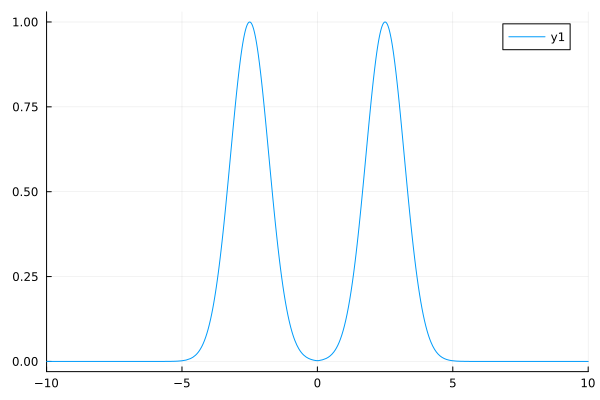

In [5]:
plot(exp(-(r(x,0,0) - L/4)^2/r0^2), xlim = (-L,L))

In [11]:

# Neural network

N_input = 4   #(t,x,y,z)
N_neurons = 64
N_layers = 3
N_output = 1

activation_function = σ
#activation_function = tanh 

@show (N_input * N_neurons + N_layers * N_neurons^2  + N_neurons * N_output    
                        + (1+N_layers) * N_neurons + N_output)

#chain = Chain(Dense(N_input, N_neurons, σ), Dense(N_neurons, N_neurons, σ), Dense(N_neurons, N_output))
chain = Lux.Chain(Lux.Dense(N_input, N_neurons, activation_function),
        [Lux.Dense(N_neurons, N_neurons, activation_function) for _ in 1:N_layers]...,
        Lux.Dense(N_neurons, N_output))

ps = Lux.setup(Random.default_rng(), chain)[1]
ps = ps |> ComponentArray |> gpud .|> Float64

#strategy = QuasiRandomTraining(15000)
strategy = QuadratureTraining(; abstol = 1e-6, reltol = 1e-6, batch = 12000) #100 es good enough for the simple ids.
#strategy = GridTraining(dx)
discretization = PhysicsInformedNN(chain, strategy; init_params = ps#, param_estim = true
#, additional_loss = additional_loss
)


N_input * N_neurons + N_layers * N_neurons ^ 2 + N_neurons * N_output + (1 + N_layers) * N_neurons + N_output = 12865


PhysicsInformedNN{Chain{@NamedTuple{layer_1::Dense{typeof(σ), Int64, Int64, Nothing, Nothing, Static.True}, layer_2::Dense{typeof(σ), Int64, Int64, Nothing, Nothing, Static.True}, layer_3::Dense{typeof(σ), Int64, Int64, Nothing, Nothing, Static.True}, layer_4::Dense{typeof(σ), Int64, Int64, Nothing, Nothing, Static.True}, layer_5::Dense{typeof(identity), Int64, Int64, Nothing, Nothing, Static.True}}, Nothing}, QuadratureTraining{Float64, Integrals.CubatureJLh}, ComponentVector{Float64, Vector{Float64}, Tuple{Axis{(layer_1 = ViewAxis(1:320, Axis(weight = ViewAxis(1:256, ShapedAxis((64, 4))), bias = ViewAxis(257:320, Shaped1DAxis((64,))))), layer_2 = ViewAxis(321:4480, Axis(weight = ViewAxis(1:4096, ShapedAxis((64, 64))), bias = ViewAxis(4097:4160, Shaped1DAxis((64,))))), layer_3 = ViewAxis(4481:8640, Axis(weight = ViewAxis(1:4096, ShapedAxis((64, 64))), bias = ViewAxis(4097:4160, Shaped1DAxis((64,))))), layer_4 = ViewAxis(8641:12800, Axis(weight = ViewAxis(1:4096, ShapedAxis((64, 64))),

In [12]:
maxiters = 3_000
prob = discretize(wave, discretization)
sym_prob = symbolic_discretize(wave, discretization)

pde_inner_loss_functions = sym_prob.loss_functions.pde_loss_functions
bcs_inner_loss_functions = sym_prob.loss_functions.bc_loss_functions

loss = Float64[]
callback = function (p, l)
    push!(loss, l)
    println("loss: ", l)
    println("pde_losses: ", map(l_ -> l_(p.u), pde_inner_loss_functions))
    println("bcs_losses: ", map(l_ -> l_(p.u), bcs_inner_loss_functions))
    return false
end
#discretization = PhysicsInformedNN(chain, GridTraining(dx))

@named wave = PDESystem(eq, bcs, domains, [t, x, y, z], [u(t, x, y, z)])
prob = discretize(wave, discretization)

OptimizationProblem. In-place: true
u0: ComponentVector{Float64}(layer_1 = (weight = [0.3330385982990265 -0.44030267000198364 -0.30671748518943787 -0.17161111533641815; -0.6091172695159912 -0.12436267733573914 -0.2943252921104431 0.14542555809020996; … ; -0.18403935432434082 0.3810446262359619 -0.8611292839050293 -0.24480333924293518; -0.25305187702178955 0.4457111060619354 0.7466752529144287 -0.8184003233909607], bias = [-0.24070024490356445, 0.1791723370552063, -0.3682704567909241, 0.32257163524627686, 0.13713473081588745, -0.3653642535209656, 0.04856079816818237, 0.01727914810180664, -0.07317721843719482, -0.05467045307159424  …  0.029535233974456787, -0.31330209970474243, 0.4154898524284363, 0.2463597059249878, 0.42168790102005005, -0.4135257601737976, -0.25211942195892334, -0.21070915460586548, -0.23346763849258423, 0.33745425939559937]), layer_2 = (weight = [0.07630198448896408 -0.20809628069400787 … 0.1307942122220993 0.12634772062301636; -0.08200386166572571 -0.1245945021510124

In [13]:
#opt = OptimizationOptimJL.BFGS()
opt = OptimizationOptimJL.SSBroyden()
res = Optimization.solve(prob, opt; callback, maxiters = maxiters)


BoundsError: BoundsError: attempt to access Tuple{Matrix{Int64}, Matrix{Float64}} at index [3]

In [9]:

phi = discretization.phi

NeuralPDE.Phi{StatefulLuxLayer{Val{true}, Chain{@NamedTuple{layer_1::Dense{typeof(σ), Int64, Int64, Nothing, Nothing, Static.True}, layer_2::Dense{typeof(σ), Int64, Int64, Nothing, Nothing, Static.True}, layer_3::Dense{typeof(σ), Int64, Int64, Nothing, Nothing, Static.True}, layer_4::Dense{typeof(σ), Int64, Int64, Nothing, Nothing, Static.True}, layer_5::Dense{typeof(identity), Int64, Int64, Nothing, Nothing, Static.True}}, Nothing}, Nothing, @NamedTuple{layer_1::@NamedTuple{}, layer_2::@NamedTuple{}, layer_3::@NamedTuple{}, layer_4::@NamedTuple{}, layer_5::@NamedTuple{}}}}(StatefulLuxLayer{Val{true}, Chain{@NamedTuple{layer_1::Dense{typeof(σ), Int64, Int64, Nothing, Nothing, Static.True}, layer_2::Dense{typeof(σ), Int64, Int64, Nothing, Nothing, Static.True}, layer_3::Dense{typeof(σ), Int64, Int64, Nothing, Nothing, Static.True}, layer_4::Dense{typeof(σ), Int64, Int64, Nothing, Nothing, Static.True}, layer_5::Dense{typeof(identity), Int64, Int64, Nothing, Nothing, Static.True}}, Nothi